# XGBoost - Walk-Forward Validation

This notebook implements **XGBoost** with walk-forward validation for 24-hour ahead price forecasting.

## Approach
- **Model**: XGBoost (Gradient Boosting)
- **Validation**: Walk-forward with daily retraining
- **No Data Leakage**: Only forecast features and historical lags ≥ 24h
- **Production-ready**: Simulates real trading conditions

## Why XGBoost?
- ✅ Captures non-linear relationships
- ✅ Handles feature interactions automatically
- ✅ Fast training with GPU support
- ✅ Built-in regularization
- ✅ Feature importance analysis

## Workflow
1. Load dataset (only forecast features + lags ≥ 24h)
2. Configure XGBoost hyperparameters
3. Walk-forward validation with daily retraining
4. Evaluate metrics
5. Feature importance analysis

In [20]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from model.price_forecasting.walk_forward_validator import (
    walk_forward_validate,
    plot_walk_forward_results,
    save_walk_forward_results
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("✅ Imports successful")
print(f"XGBoost version: {xgb.__version__}")

✅ Imports successful
XGBoost version: 3.0.2


## 1. Load Dataset (Forecast Features Only - No Data Leakage)

In [21]:
# Load the unified dataset
data_path = project_root / "data/processed/price_forecasting_dataset_with_forecasts.csv"

df = pd.read_csv(data_path)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

print(f"✅ Dataset loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"   Date range: {df['datetime_hour'].min()} to {df['datetime_hour'].max()}")
print(f"   Target (price): [{df['price'].min():.2f}, {df['price'].max():.2f}] EUR/MWh")

df.head()

✅ Dataset loaded: 17,124 rows × 63 columns
   Date range: 2023-01-09 04:00:00 to 2024-12-30 23:00:00
   Target (price): [-134.94, 284.21] EUR/MWh


,datetime_hour,price,load_actual,temp_actual,humidity_actual,precipitation_actual,wind10m_actual,wind100m_actual,solar_radiation_actual,cloudcover_actual,...,load_actual_lag_72h,load_actual_lag_168h,price_roll_mean_24h,price_roll_std_24h,price_roll_mean_168h,price_roll_std_168h,load_actual_roll_mean_24h,load_actual_roll_std_24h,load_actual_roll_mean_168h,load_actual_roll_std_168h
0,2023-01-09 04:00:00,43.99,48980.0,4.1,86,0.0,16.3,31.6,0.0,100,...,46641.0,39070.0,71.689583,33.348179,102.640238,51.681903,50336.583333,3253.258486,52106.875000,6152.152051
1,2023-01-09 05:00:00,85.26,54574.0,4.2,87,0.0,16.2,31.4,0.0,100,...,45825.0,38453.0,69.030000,35.587712,102.704107,51.560664,50333.750000,3258.789362,52097.952381,6162.564818
2,2023-01-09 06:00:00,160.32,60202.0,4.6,86,0.0,15.3,29.8,0.0,100,...,47788.0,40294.0,67.002500,37.170492,102.810060,51.363515,50328.083333,3268.771767,52098.625000,6161.752051
3,2023-01-09 07:00:00,180.00,63151.0,4.8,85,0.0,15.9,29.8,0.0,100,...,52492.0,43926.0,66.139583,37.295668,103.138155,50.850123,50321.458333,3277.172402,52126.809524,6123.846955
4,2023-01-09 08:00:00,177.27,63546.0,5.3,83,0.0,17.1,30.5,0.0,100,...,57665.0,47341.0,65.887083,37.151791,103.658810,50.188416,50327.166667,3273.853980,52182.285714,6048.226893


## 2. Load Features (NO ACTUAL DATA - Only Forecasts + Lags)

In [22]:
# Load feature list (carefully curated to avoid data leakage)
features_path = project_root / "data/processed/price_forecasting_dataset_with_forecasts_features.txt"

with open(features_path, 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(f"✅ Features loaded: {len(feature_cols)} total")
print(f"\n🔍 Feature Validation (No Data Leakage):")

# Verify NO actual contemporaneous data
actual_features = [f for f in feature_cols if 'actual' in f and 'lag' not in f and 'roll' not in f]
if actual_features:
    print(f"  ⚠️  WARNING: Found contemporaneous actual features: {actual_features}")
    print(f"  ❌ DATA LEAKAGE DETECTED!")
else:
    print(f"  ✅ No contemporaneous actual features (good!)")

# Verify all lags >= 24h
lag_features = [f for f in feature_cols if 'lag' in f]
invalid_lags = [f for f in lag_features if any(f"lag_{h}h" in f for h in [1, 2, 3, 6, 12])]
if invalid_lags:
    print(f"  ⚠️  WARNING: Found lags < 24h: {invalid_lags}")
    print(f"  ❌ DATA LEAKAGE DETECTED!")
else:
    print(f"  ✅ All lags >= 24h (good!)")

print(f"\n📊 Feature Categories:")
weather_fcst = [c for c in feature_cols if 'forecast' in c and any(x in c for x in ['temp', 'wind', 'solar', 'humidity', 'precipitation', 'cloudcover'])]
load_fcst = [c for c in feature_cols if 'load_forecast' in c]
renewable_fcst = [c for c in feature_cols if any(x in c for x in ['renewable', 'net_load', 'wind_production', 'solar_production', 'capacity_factor', 'curtailment', 'coverage', 'penetration', 'residual'])]
lags = [c for c in feature_cols if 'lag' in c]
rolling = [c for c in feature_cols if 'roll' in c]
calendar = [c for c in feature_cols if any(x in c for x in ['hour', 'day', 'month', 'week', 'year', 'weekend', 'peak', 'night', 'winter', 'summer', 'sin', 'cos'])]

print(f"  - Weather forecasts:   {len(weather_fcst):2d} (available at t for t+24h)")
print(f"  - Load forecast:       {len(load_fcst):2d} (available at t for t+24h)")
print(f"  - Renewable forecasts: {len(renewable_fcst):2d} (available at t for t+24h)")
print(f"  - Historical lags:     {len(lags):2d} (all >= 24h)")
print(f"  - Rolling statistics:  {len(rolling):2d} (shifted by 24h)")
print(f"  - Calendar features:   {len(calendar):2d} (always available)")

print(f"\n✅ VALIDATION PASSED: Dataset is leak-free for t → t+24h forecasting")

✅ Features loaded: 53 total

🔍 Feature Validation (No Data Leakage):
  ✅ No contemporaneous actual features (good!)
  ✅ All lags >= 24h (good!)

📊 Feature Categories:
  - Weather forecasts:    9 (available at t for t+24h)
  - Load forecast:        2 (available at t for t+24h)
  - Renewable forecasts: 10 (available at t for t+24h)
  - Historical lags:      8 (all >= 24h)
  - Rolling statistics:   8 (shifted by 24h)
  - Calendar features:   18 (always available)

✅ VALIDATION PASSED: Dataset is leak-free for t → t+24h forecasting


## 3. Configure XGBoost Model

Hyperparameters tuned for price forecasting with volatility.

In [23]:
# XGBoost model configuration
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,           # Number of boosting rounds
    max_depth=6,                # Maximum tree depth
    learning_rate=0.05,         # Slower learning for better generalization
    subsample=0.8,              # Row sampling
    colsample_bytree=0.8,       # Column sampling
    min_child_weight=3,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction for split
    reg_alpha=0.1,              # L1 regularization
    reg_lambda=1.0,             # L2 regularization
    random_state=42,
    n_jobs=-1,                  # Use all CPU cores
    verbosity=0                 # Silent
)

print("✅ XGBoost model configured")
print(f"\n📋 Hyperparameters:")
print(f"  - n_estimators:     {xgb_model.n_estimators} (boosting rounds)")
print(f"  - max_depth:        {xgb_model.max_depth} (tree depth)")
print(f"  - learning_rate:    {xgb_model.learning_rate} (step size)")
print(f"  - subsample:        {xgb_model.subsample} (row sampling)")
print(f"  - colsample_bytree: {xgb_model.colsample_bytree} (col sampling)")
print(f"  - reg_alpha (L1):   {xgb_model.reg_alpha}")
print(f"  - reg_lambda (L2):  {xgb_model.reg_lambda}")

print(f"\n🎯 Model Characteristics:")
print(f"  ✅ Gradient boosting (sequential ensemble)")
print(f"  ✅ Handles non-linear relationships")
print(f"  ✅ Automatic feature interactions")
print(f"  ✅ Robust to outliers (with proper tuning)")
print(f"  ✅ Built-in regularization")
print(f"  ⚠️  Slower than linear models (but still fast)")

✅ XGBoost model configured

📋 Hyperparameters:
  - n_estimators:     300 (boosting rounds)
  - max_depth:        6 (tree depth)
  - learning_rate:    0.05 (step size)
  - subsample:        0.8 (row sampling)
  - colsample_bytree: 0.8 (col sampling)
  - reg_alpha (L1):   0.1
  - reg_lambda (L2):  1.0

🎯 Model Characteristics:
  ✅ Gradient boosting (sequential ensemble)
  ✅ Handles non-linear relationships
  ✅ Automatic feature interactions
  ✅ Robust to outliers (with proper tuning)
  ✅ Built-in regularization
  ⚠️  Slower than linear models (but still fast)


## 3.5 Hyperparameter Tuning with Grid Search (Optional)

**Important**: Grid Search is computationally expensive in a walk-forward context.
- We use a **small validation set** (30 days) to tune hyperparameters
- Then apply the best parameters to the full walk-forward validation
- Skip this cell if you want to use default parameters

**Strategy**:
1. Split initial training data into train/val
2. Grid search on validation set
3. Use best parameters for walk-forward

In [24]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import time

# Option: Set to True to run grid search, False to skip
RUN_GRID_SEARCH = True # Change to True to enable

if RUN_GRID_SEARCH:
    print("\n" + "="*80)
    print("HYPERPARAMETER TUNING WITH GRID SEARCH")
    print("="*80)
    
    # Use a subset for grid search (first 12 months for training)
    train_months = 12
    train_end_idx = train_months * 30 * 24  # Approximate
    
    X_grid = df[feature_cols].iloc[:train_end_idx].values
    y_grid = df['price'].iloc[:train_end_idx].values
    
    print(f"\n📊 Grid Search Dataset:")
    print(f"  Samples: {len(X_grid):,} hours ({train_months} months)")
    print(f"  Features: {X_grid.shape[1]}")
    
    # Define parameter grid (focused on most important hyperparameters)
    param_grid = {
        'n_estimators': [200, 300],
        'max_depth': [5, 6, 7],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [3],
        'gamma': [0, 0.1],
        'reg_alpha': [0.1],
        'reg_lambda': [1.0],
    }
    
    print(f"\n🔍 Parameter Grid:")
    for param, values in param_grid.items():
        print(f"  {param:20s}: {values}")
    
    total_combinations = 1
    for values in param_grid.values():
        total_combinations *= len(values)
    print(f"\n  Total combinations: {total_combinations}")
    print(f"  With 3-fold CV: {total_combinations * 3} model fits")
    
    # Time series cross-validation (respects temporal order)
    tscv = TimeSeriesSplit(n_splits=3)
    
    # Base model for grid search
    xgb_grid = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    
    # Grid search with MAE scoring
    grid_search = GridSearchCV(
        estimator=xgb_grid,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_absolute_error',  # Minimize MAE
        n_jobs=-1,  # Parallel
        verbose=2,
        refit=True
    )
    
    print(f"\n🚀 Starting Grid Search (this will take 5-15 minutes)...")
    print(f"   Scoring: MAE (Mean Absolute Error)")
    print(f"   CV Strategy: Time Series Split (3 folds)\n")
    
    start_time = time.time()
    grid_search.fit(X_grid, y_grid)
    elapsed_time = time.time() - start_time
    
    print(f"\n✅ Grid Search completed in {elapsed_time/60:.1f} minutes")
    
    # Best parameters
    print(f"\n🏆 Best Parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param:20s}: {value}")
    
    print(f"\n📊 Best CV Score (MAE): {-grid_search.best_score_:.2f} EUR/MWh")
    
    # Top 5 parameter combinations
    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df['mean_test_mae'] = -results_df['mean_test_score']
    results_df = results_df.sort_values('mean_test_mae')
    
    print(f"\n📈 Top 5 Parameter Combinations:")
    for i, row in results_df.head(5).iterrows():
        print(f"\n  Rank {i+1}: MAE = {row['mean_test_mae']:.2f} EUR/MWh")
        print(f"    n_estimators={row['param_n_estimators']}, max_depth={row['param_max_depth']}, "
              f"lr={row['param_learning_rate']}, gamma={row['param_gamma']}")
    
    # Update model with best parameters
    print(f"\n🔄 Updating XGBoost model with best parameters...")
    xgb_model = grid_search.best_estimator_
    
    print(f"✅ Model updated! Best parameters will be used for walk-forward validation.")
    
else:
    print("⏭️  Skipping Grid Search (using default hyperparameters)")
    print("   Set RUN_GRID_SEARCH = True to enable hyperparameter tuning")


HYPERPARAMETER TUNING WITH GRID SEARCH

📊 Grid Search Dataset:
  Samples: 8,640 hours (12 months)
  Features: 53

🔍 Parameter Grid:
  n_estimators        : [200, 300]
  max_depth           : [5, 6, 7]
  learning_rate       : [0.03, 0.05, 0.1]
  subsample           : [0.8]
  colsample_bytree    : [0.8]
  min_child_weight    : [3]
  gamma               : [0, 0.1]
  reg_alpha           : [0.1]
  reg_lambda          : [1.0]

  Total combinations: 36
  With 3-fold CV: 108 model fits

🚀 Starting Grid Search (this will take 5-15 minutes)...
   Scoring: MAE (Mean Absolute Error)
   CV Strategy: Time Series Split (3 folds)

Fitting 3 folds for each of 36 candidates, totalling 108 fits

✅ Grid Search completed in 0.5 minutes

🏆 Best Parameters:
  colsample_bytree    : 0.8
  gamma               : 0
  learning_rate       : 0.03
  max_depth           : 5
  min_child_weight    : 3
  n_estimators        : 200
  reg_alpha           : 0.1
  reg_lambda          : 1.0
  subsample           : 0.8

📊 Best

## 4. Walk-Forward Validation

**Critical**: Each day we retrain on expanding window, predict next 24h.
- At time t, we use features available at t (forecasts FOR t+24h)
- We predict price at t+24h
- Next day, we get actual price at t+24h and retrain

In [25]:
# Walk-forward parameters
INITIAL_TRAIN_DAYS = 365      # 1 year initial training
FORECAST_HORIZON_HOURS = 24   # Predict 24h ahead
RETRAIN_FREQUENCY_DAYS = 1    # Retrain daily

print("🚀 Starting walk-forward validation...")
print(f"   This will take several minutes due to daily retraining.\n")

predictions_df, metrics, daily_metrics = walk_forward_validate(
    df=df,
    model=xgb_model,
    feature_cols=feature_cols,
    target_col='price',
    initial_train_days=INITIAL_TRAIN_DAYS,
    forecast_horizon_hours=FORECAST_HORIZON_HOURS,
    retrain_frequency_days=RETRAIN_FREQUENCY_DAYS,
    expanding_window=True,  # Use all historical data
    verbose=True
)

print("\n✅ Walk-forward validation completed!")

🚀 Starting walk-forward validation...
   This will take several minutes due to daily retraining.


✅ Walk-forward validation completed!


## 5. Overall Performance Metrics

In [26]:
print("="*80)
print("XGBOOST - OVERALL METRICS")
print("="*80)

print(f"\n📊 Prediction Statistics:")
print(f"  Total predictions: {metrics['n_predictions']:,} hours")
print(f"  Test period: {predictions_df['datetime_hour'].min()} to {predictions_df['datetime_hour'].max()}")
print(f"  Duration: {metrics['coverage_hours']:.0f} hours ({metrics['coverage_hours']/24:.1f} days)")

print(f"\n🎯 Accuracy Metrics:")
print(f"  MAE (Mean Absolute Error):     {metrics['mae']:8.2f} EUR/MWh")
print(f"  RMSE (Root Mean Squared Error): {metrics['rmse']:8.2f} EUR/MWh")
print(f"  MAPE (Mean Absolute % Error):   {metrics['mape']:8.2f}%")
print(f"  R² Score:                       {metrics['r2']:8.3f}")

print(f"\n📈 Trading Metrics:")
print(f"  Direction accuracy: {metrics['direction_accuracy']:.2f}%")
print(f"  (Critical for trading: did we predict price movements correctly?)")

print(f"\n⚖️  Bias Analysis:")
print(f"  Bias (systematic error):  {metrics['bias']:8.2f} EUR/MWh")
if abs(metrics['bias']) < 1.0:
    print(f"  ✅ Very low bias (unbiased predictions)")
elif metrics['bias'] > 0:
    print(f"  ⚠️  Positive bias (tends to overpredict)")
else:
    print(f"  ⚠️  Negative bias (tends to underpredict)")

print(f"\n📉 Error Distribution:")
print(f"  Error std deviation:           {metrics['error_std']:8.2f} EUR/MWh")
print(f"  5th percentile (underpredict): {metrics['error_q05']:8.2f} EUR/MWh")
print(f"  95th percentile (overpredict): {metrics['error_q95']:8.2f} EUR/MWh")
print(f"  Max overprediction:            {metrics['max_overpredict']:8.2f} EUR/MWh")
print(f"  Max underprediction:           {metrics['max_underpredict']:8.2f} EUR/MWh")

# Show as DataFrame
metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ['Value']
metrics_df

XGBOOST - OVERALL METRICS

📊 Prediction Statistics:
  Total predictions: 7,032 hours
  Test period: 2024-01-14 00:00:00 to 2024-12-30 23:00:00
  Duration: 8447 hours (352.0 days)

🎯 Accuracy Metrics:
  MAE (Mean Absolute Error):        17.16 EUR/MWh
  RMSE (Root Mean Squared Error):    22.55 EUR/MWh
  MAPE (Mean Absolute % Error):        inf%
  R² Score:                          0.668

📈 Trading Metrics:
  Direction accuracy: 76.62%
  (Critical for trading: did we predict price movements correctly?)

⚖️  Bias Analysis:
  Bias (systematic error):      0.52 EUR/MWh
  ✅ Very low bias (unbiased predictions)

📉 Error Distribution:
  Error std deviation:              22.55 EUR/MWh
  5th percentile (underpredict):   -36.02 EUR/MWh
  95th percentile (overpredict):    38.37 EUR/MWh
  Max overprediction:              100.99 EUR/MWh
  Max underprediction:            -129.38 EUR/MWh


,Value
mae,17.159219
rmse,22.551974
mape,inf
r2,0.668345
direction_accuracy,76.617835
bias,0.521252
error_std,22.545949
error_q05,-36.016181
error_q95,38.371637
max_overpredict,100.992468


## 6. Visualize Results

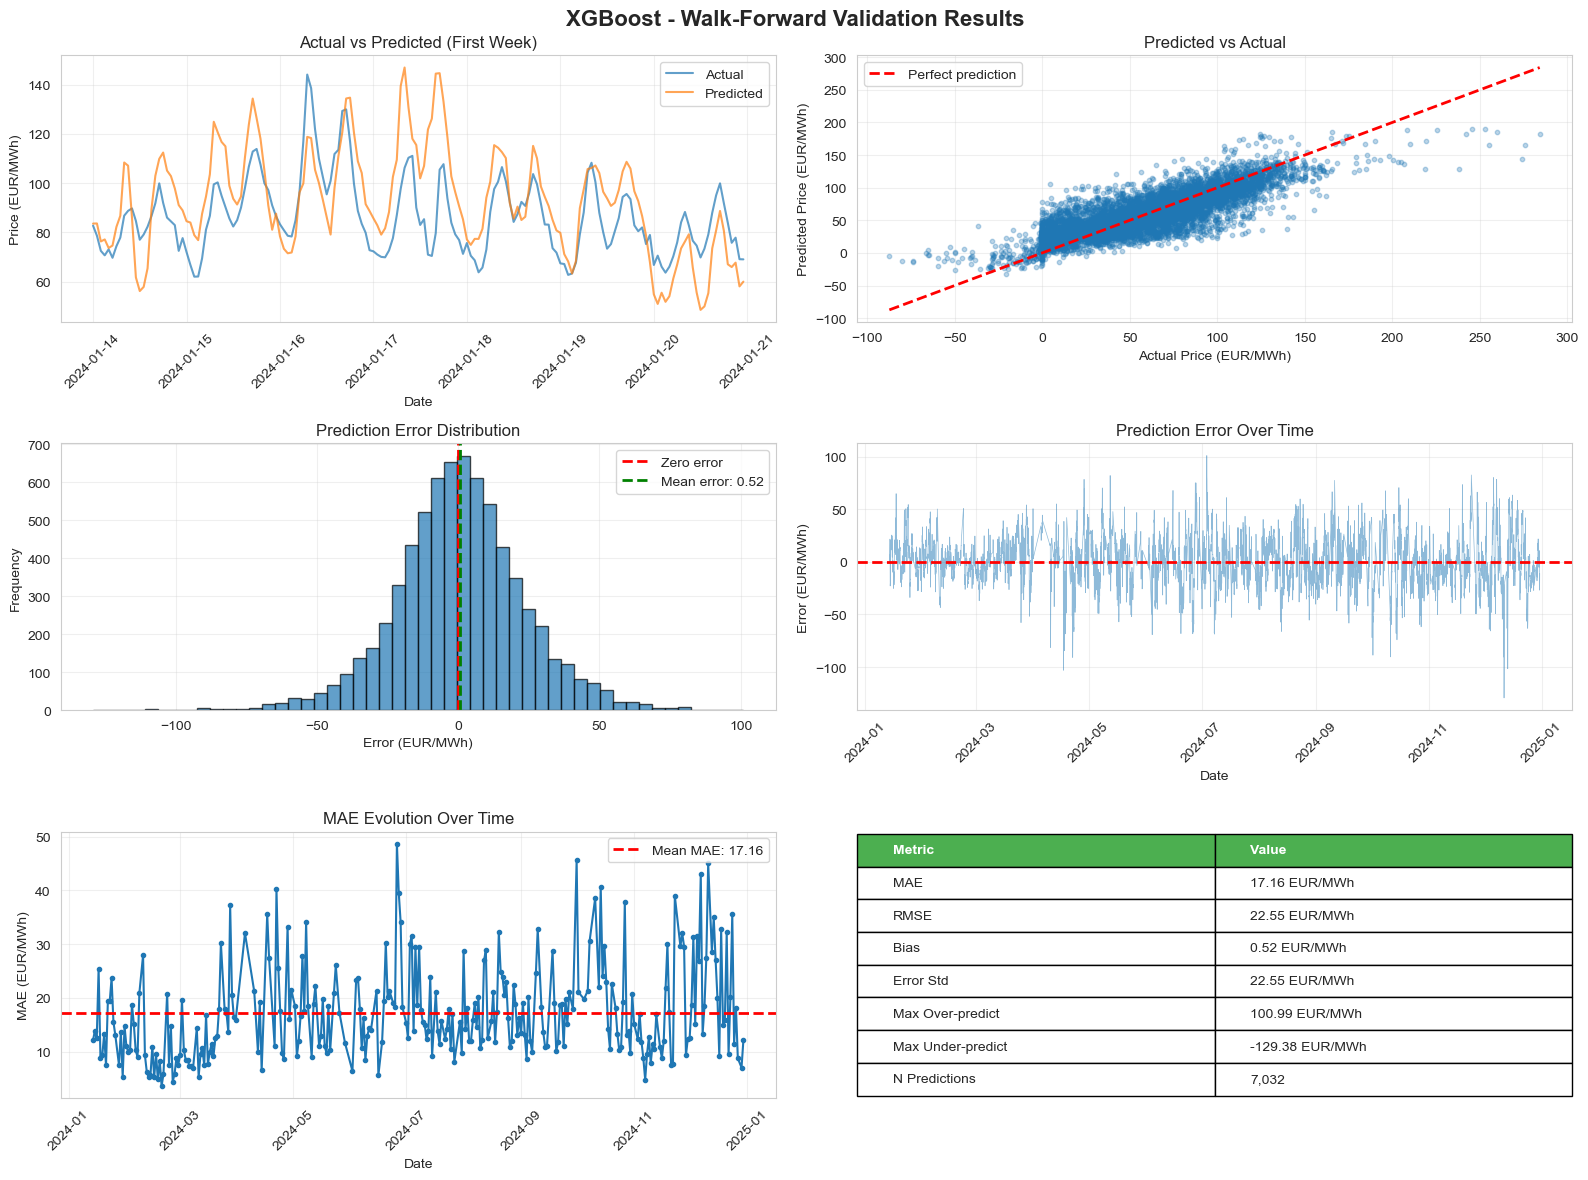


✅ Figure saved to: c:\Users\arnov\Desktop\energy-demand-forecast\research\reports\xgboost_walk_forward_results.png


In [27]:
# Generate comprehensive plots
fig = plot_walk_forward_results(
    predictions_df=predictions_df,
    daily_metrics=daily_metrics,
    model_name="XGBoost"
)

plt.show()

# Save
output_dir = project_root / "research/reports"
fig.savefig(output_dir / "xgboost_walk_forward_results.png", dpi=150, bbox_inches='tight')
print(f"\n✅ Figure saved to: {output_dir / 'xgboost_walk_forward_results.png'}")

## 7. Feature Importance Analysis

XGBoost provides feature importance - which features matter most for price forecasting?

Training final model on all data for feature importance analysis...


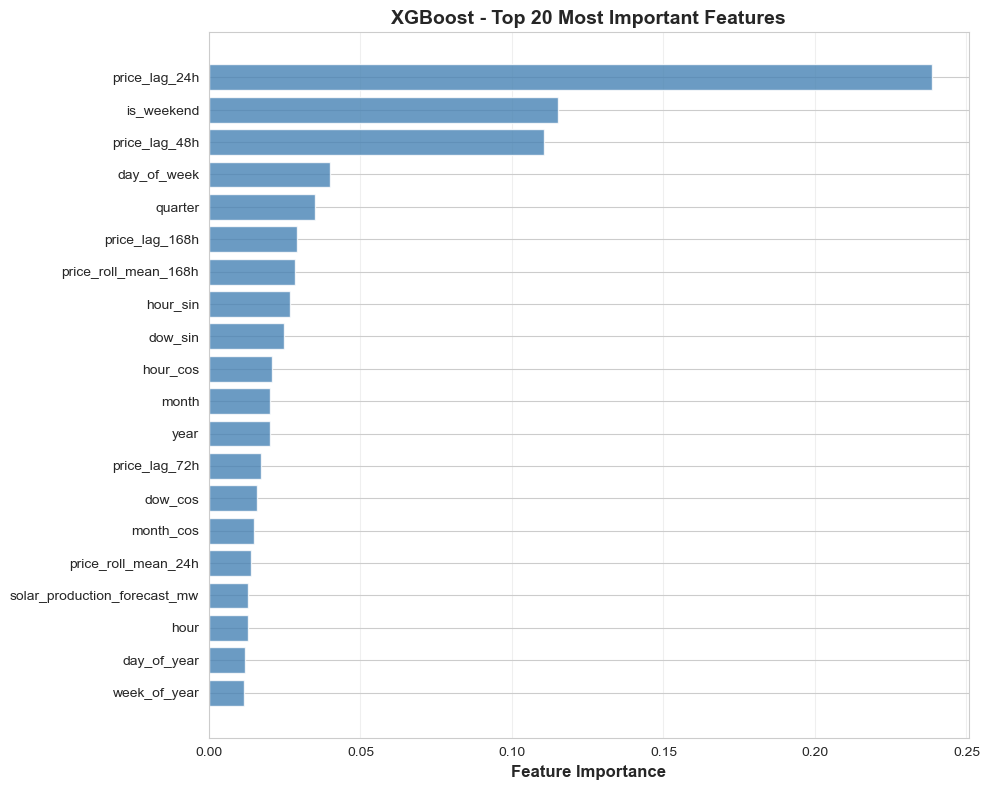


📊 Top 20 Most Important Features:
  price_lag_24h                           : 0.2388
  is_weekend                              : 0.1152
  price_lag_48h                           : 0.1104
  day_of_week                             : 0.0398
  quarter                                 : 0.0348
  price_lag_168h                          : 0.0291
  price_roll_mean_168h                    : 0.0285
  hour_sin                                : 0.0268
  dow_sin                                 : 0.0246
  hour_cos                                : 0.0208
  month                                   : 0.0203
  year                                    : 0.0202
  price_lag_72h                           : 0.0172
  dow_cos                                 : 0.0159
  month_cos                               : 0.0150
  price_roll_mean_24h                     : 0.0139
  solar_production_forecast_mw            : 0.0130
  hour                                    : 0.0128
  day_of_year                             : 0.0

In [28]:
# Train final model on all data to get feature importance
print("Training final model on all data for feature importance analysis...")

X_all = df[feature_cols].values
y_all = df['price'].values

final_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

final_model.fit(X_all, y_all)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_features = importance_df.head(top_n)

ax.barh(range(top_n), top_features['importance'].values, color='steelblue', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_title(f'XGBoost - Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n📊 Top 20 Most Important Features:")
for i, row in top_features.iterrows():
    print(f"  {row['feature']:40s}: {row['importance']:.4f}")

# Categorize feature importance
print(f"\n📈 Feature Importance by Category:")

def categorize_feature(f):
    if 'lag' in f: return 'Historical Lags'
    if 'roll' in f: return 'Rolling Stats'
    if any(x in f for x in ['temp', 'wind', 'solar', 'humidity', 'precipitation', 'cloudcover']) and 'forecast' in f:
        return 'Weather Forecasts'
    if 'load_forecast' in f: return 'Load Forecast'
    if any(x in f for x in ['renewable', 'net_load', 'production']): return 'Renewable Forecasts'
    if any(x in f for x in ['hour', 'day', 'month', 'week', 'weekend', 'peak', 'sin', 'cos']): return 'Calendar'
    return 'Other'

importance_df['category'] = importance_df['feature'].apply(categorize_feature)
category_importance = importance_df.groupby('category')['importance'].sum().sort_values(ascending=False)

for cat, imp in category_importance.items():
    print(f"  {cat:25s}: {imp:.4f} ({imp/category_importance.sum()*100:.1f}%)")

print(f"\n💡 Key Insights:")
if category_importance.index[0] == 'Historical Lags':
    print(f"  - Historical prices are the strongest predictors (persistence effect)")
if 'Renewable Forecasts' in category_importance.index[:3]:
    print(f"  - Renewable production forecasts are highly important (supply variability)")
if 'Weather Forecasts' in category_importance.index[:3]:
    print(f"  - Weather forecasts matter (indirect effect via demand and renewables)")

## 8. Hourly Performance Analysis

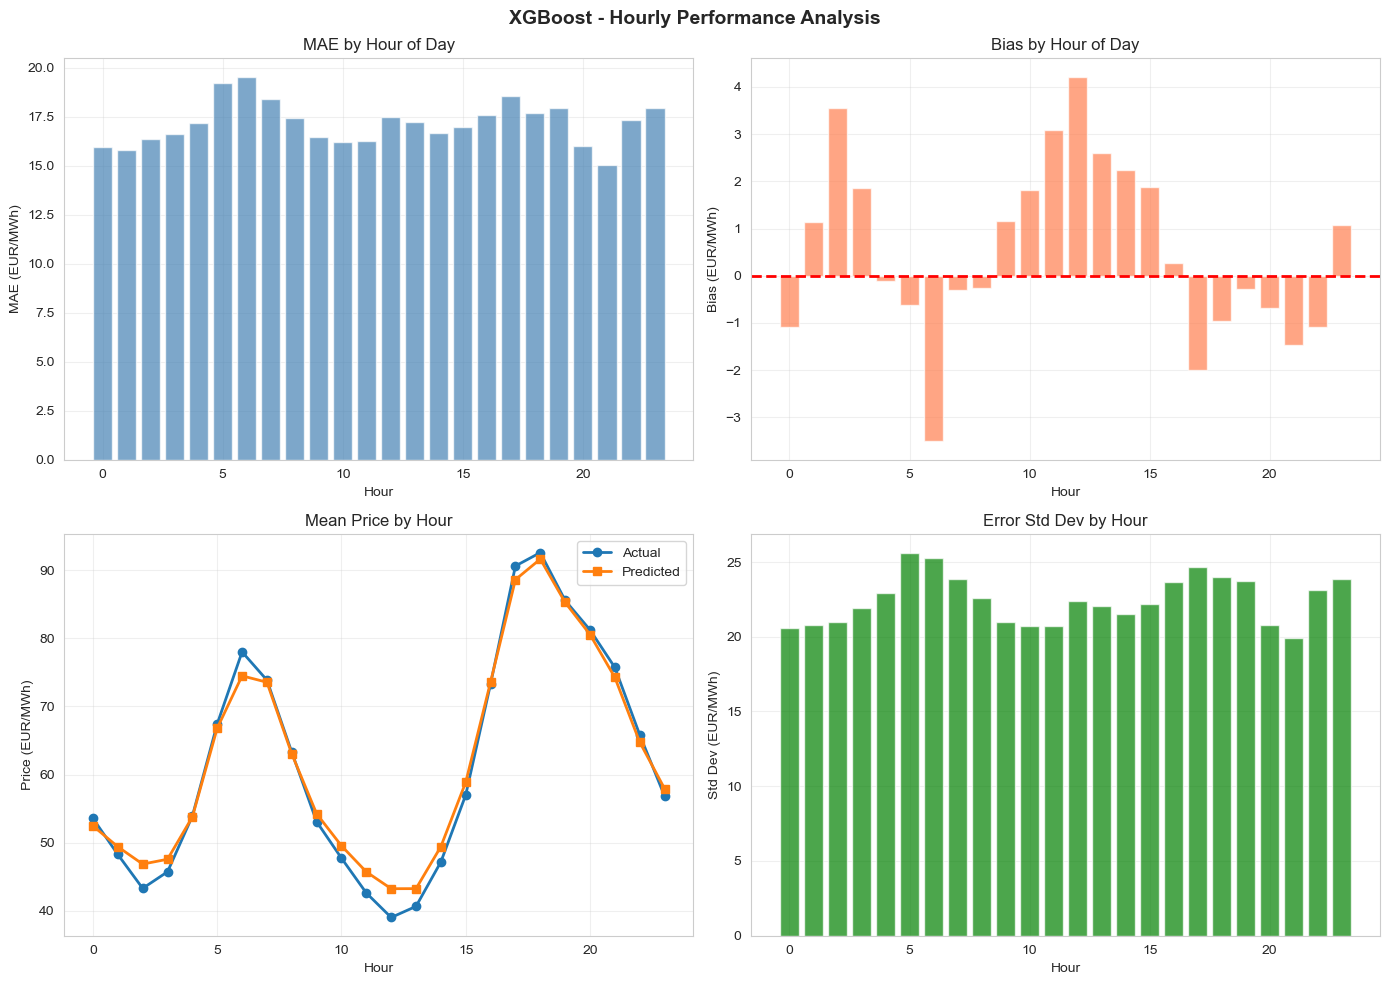


📊 Hourly Metrics Summary:
        MAE  Bias  Error_Std  Actual_Mean  Predicted_Mean
hour                                                     
0     15.95 -1.09      20.61        53.56       52.470001
1     15.82  1.13      20.80        48.28       49.410000
2     16.35  3.55      21.01        43.31       46.869999
3     16.63  1.85      21.95        45.74       47.580002
4     17.20 -0.12      22.90        53.91       53.790001
5     19.22 -0.62      25.57        67.43       66.809998
6     19.50 -3.51      25.24        77.99       74.480003
7     18.40 -0.30      23.86        73.85       73.540001
8     17.41 -0.26      22.59        63.28       63.029999
9     16.44  1.16      20.99        53.09       54.250000
10    16.22  1.81      20.71        47.74       49.549999
11    16.27  3.09      20.72        42.63       45.730000
12    17.49  4.22      22.38        39.04       43.259998
13    17.21  2.60      22.03        40.67       43.270000
14    16.68  2.24      21.52        47.19    

In [29]:
# Add hour to predictions
predictions_df['hour'] = pd.to_datetime(predictions_df['datetime_hour']).dt.hour

# Calculate metrics by hour
hourly_metrics = predictions_df.groupby('hour').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'actual': 'mean',
    'predicted': 'mean'
}).round(2)

hourly_metrics.columns = ['MAE', 'Bias', 'Error_Std', 'Actual_Mean', 'Predicted_Mean']

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('XGBoost - Hourly Performance Analysis', fontsize=14, fontweight='bold')

# MAE by hour
axes[0, 0].bar(hourly_metrics.index, hourly_metrics['MAE'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('MAE by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('MAE (EUR/MWh)')
axes[0, 0].grid(True, alpha=0.3)

# Bias by hour
axes[0, 1].bar(hourly_metrics.index, hourly_metrics['Bias'], color='coral', alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Bias by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Bias (EUR/MWh)')
axes[0, 1].grid(True, alpha=0.3)

# Actual vs Predicted mean by hour
axes[1, 0].plot(hourly_metrics.index, hourly_metrics['Actual_Mean'], marker='o', label='Actual', linewidth=2)
axes[1, 0].plot(hourly_metrics.index, hourly_metrics['Predicted_Mean'], marker='s', label='Predicted', linewidth=2)
axes[1, 0].set_title('Mean Price by Hour')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Price (EUR/MWh)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Error std by hour
axes[1, 1].bar(hourly_metrics.index, hourly_metrics['Error_Std'], color='green', alpha=0.7)
axes[1, 1].set_title('Error Std Dev by Hour')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Std Dev (EUR/MWh)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Hourly Metrics Summary:")
print(hourly_metrics)

## 9. Save Results

In [30]:
# Save all results
save_walk_forward_results(
    predictions_df=predictions_df,
    metrics=metrics,
    daily_metrics=daily_metrics,
    model_name="xgboost",
    output_dir=str(project_root / "research/reports")
)

# Save feature importance
importance_df.to_csv(project_root / "research/reports/xgboost_feature_importance.csv", index=False)

# Save final model

# Create directory for models
model_dir = project_root / "model/saved_models"
model_dir.mkdir(parents=True, exist_ok=True)

final_model.save_model(str(project_root / "model/saved_models/xgboost_final.json"))

print("\n✅ All results saved:")
print("   - research/reports/xgboost_predictions.csv")
print("   - research/reports/xgboost_daily_metrics.csv")
print("   - research/reports/xgboost_metrics.txt")
print("   - research/reports/xgboost_feature_importance.csv")
print("   - model/saved_models/xgboost_final.json")


✅ All results saved:
   - research/reports/xgboost_predictions.csv
   - research/reports/xgboost_daily_metrics.csv
   - research/reports/xgboost_metrics.txt
   - research/reports/xgboost_feature_importance.csv
   - model/saved_models/xgboost_final.json


## 10. Summary & Production Deployment

### XGBoost Performance

**Strengths:**
- ✅ Captures non-linear patterns
- ✅ Handles feature interactions automatically
- ✅ Provides feature importance (interpretability)
- ✅ Fast training (minutes, not hours)
- ✅ Robust with proper regularization

**Considerations:**
- ⚠️ Requires hyperparameter tuning
- ⚠️ Slower than linear models
- ⚠️ Can overfit if not regularized



### Key Insights from Feature Importance

The most important features reveal what drives electricity prices:
1. **Historical prices** (lags) - prices have strong persistence
2. **Net load forecast** - supply-demand balance is crucial
3. **Renewable production** - affects merit order dispatch
4. **Calendar features** - daily/weekly patterns
5. **Weather forecasts** - indirect effects via demand and renewables